In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,  models 
from tensorflow.keras.datasets import cifar10 
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Conv2D, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from keras.layers import InputLayer , GlobalAveragePooling2D
import matplotlib.pyplot as plt


In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [4]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [5]:
# Normalize pixel values to be between 0 and 1
x_train = x_train/ 255.0
x_test = x_test / 255.0

In [6]:
#Convert class vectors to binary class matrices (One hot encoding)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
base_model=VGG16(weights='imagenet', include_top=False)

In [8]:
#Freeze the layers of VGG16
for layer in base_model.layers:
    layer.trainable=False

In [9]:
#Build the model
model = Sequential()

#Define the input shape
model.add(InputLayer(input_shape=(32, 32, 3)))

#Add the VGG16 base model
model.add(base_model)

#Flatten/pool the output from VGGi16's convolutional layers
#model.add(Flatten()) use when dataset is large.preserves spatial information
model.add(GlobalAveragePooling2D())

#Add a fully connected layer with 256 units and ReLU activation 
model.add(Dense(256, activation='relu'))

#Add a dropout layer with a rate of 0.5 to prevent overfitting
model.add(Dropout(0.5))

#Add the output layer with 10 units (for 10 classes) and softmax activation
model.add(Dense(10, activation='softmax'))

#Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

#print the model summary 
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               131328    
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                        

In [10]:
#create data augmentation generator
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

In [11]:
#fit the model using data augmentation 
batch_size =64
epochs=3
train_generator=datagen.flow(x_train,y_train,batch_size=batch_size)

In [12]:
#train the model
history = model.fit(train_generator,steps_per_epoch=x_train.shape[0] //batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/3


781/781 [==============================] - 88s 110ms/step - loss: 1.9742 - accuracy: 0.2988 - val_loss: 1.6210 - val_accuracy: 0.4515
Epoch 2/3
781/781 [==============================] - 83s 106ms/step - loss: 1.6508 - accuracy: 0.4259 - val_loss: 1.4750 - val_accuracy: 0.4953
Epoch 3/3
781/781 [==============================] - 83s 106ms/step - loss: 1.5452 - accuracy: 0.4613 - val_loss: 1.4036 - val_accuracy: 0.5164


In [13]:
#evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f'Test accuracy: {test_acc:.4f}')

313/313 [==============================] - 17s 54ms/step - loss: 1.4036 - accuracy: 0.5164
Test accuracy: 0.5164


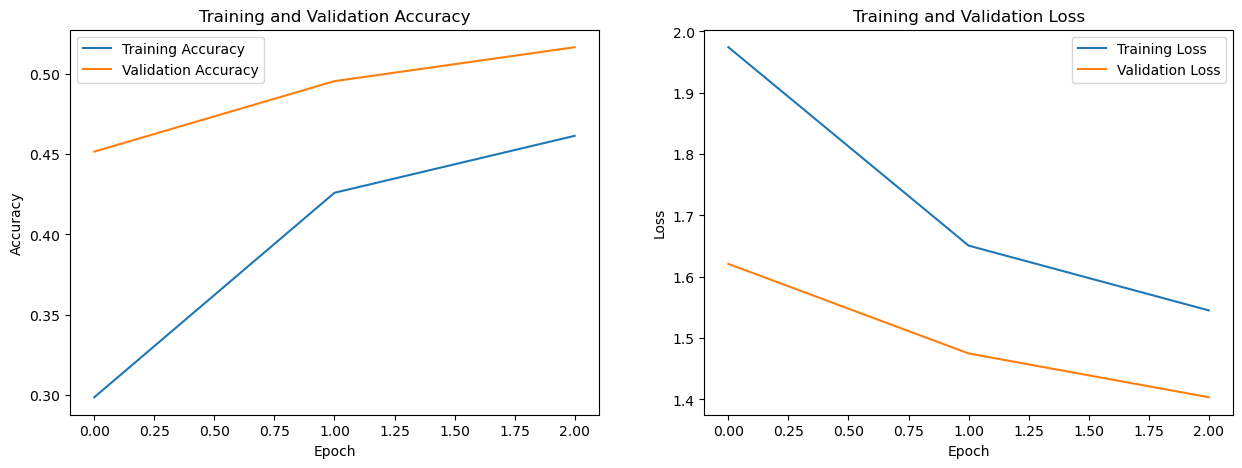

In [14]:
#plot training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
